In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [ ]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = (iris.target == 0).astype(int) # Setosa vs non-Setosa

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Build the single-layer Perceptron model using TensorFlow
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],))
])

In [ ]:
# Compile the model
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1151 - loss: 1.3680 
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1318 - loss: 1.2745
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1262 - loss: 1.1988
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1537 - loss: 1.1605
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1450 - loss: 1.1308
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1811 - loss: 1.0702
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1751 - loss: 1.0709
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1772 - loss: 1.0168
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1769 - loss: 0.9740 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2265 - loss: 0.9230
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2102 - loss: 0.8939
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2879 - 

In [ ]:
# Predict on the test set
predictions = model.predict(X_test)
binary_predictions = (predictions > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [ ]:
 # Generate classification report
class_names = ['Non-Setosa', 'Setosa'] # Order corresponds to the labels
report = classification_report(y_test, binary_predictions,target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

  Non-Setosa       1.00      1.00      1.00        26
      Setosa       1.00      1.00      1.00        19

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



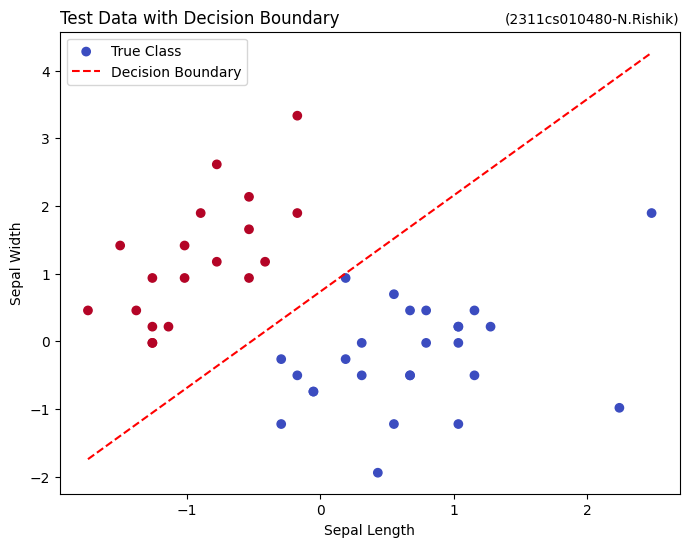

In [ ]:
# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='o',label='True Class')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
x_vals = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 100)
y_vals = (-model.weights[0][0] * x_vals - model.weights[1]) / model.weights[0][1]
plt.plot(x_vals, y_vals, 'r--', label='Decision Boundary')
plt.title('Test Data with Decision Boundary',loc='left')
plt.text(1.0,1.02,'(2311cs010480-N.Rishik)',transform=plt.gca().transAxes,ha='right')
plt.legend()
plt.show()